In [8]:
# Force reload of model_library with verification
import sys
import importlib

# Remove model_library modules
model_lib_mods = [m for m in list(sys.modules.keys()) if 'model_library' in m]
for m in model_lib_mods:
    try:
        del sys.modules[m]
    except:
        pass

# Import fresh
from model_library import run_spmet_power

# Check the actual function source
import inspect
import model_library.spmet_power as sp

source = inspect.getsource(sp._power_sweep_characterization)
has_phase1 = '# PHASE 1:' in source
has_phase2 = '# PHASE 2:' in source
has_phase3 = '# PHASE 3:' in source

print(f"✓ Module reloaded")
print(f"  Phase 1 (reduce to find feasible): {has_phase1}")
print(f"  Phase 2 (increase to find upper): {has_phase2}")
print(f"  Phase 3 (binary search): {has_phase3}")

if has_phase1 and has_phase2 and has_phase3:
    print("\n✓✓✓ NEW ALGORITHM ACTIVE ✓✓✓")
    print("  1. Start at 100kW, reduce by ÷10 until feasible")
    print("  2. Increase by ×10 to find upper bound")
    print("  3. Binary search between bounds")
else:
    print("\n⚠ WARNING: Fix not loaded properly")

✓ Module reloaded
  Phase 1 (reduce to find feasible): True
  Phase 2 (increase to find upper): True
  Phase 3 (binary search): True

✓✓✓ NEW ALGORITHM ACTIVE ✓✓✓
  1. Start at 100kW, reduce by ÷10 until feasible
  2. Increase by ×10 to find upper bound
  3. Binary search between bounds


# Direct Constant Power Characterization with PyBaMM

This notebook demonstrates true constant power discharge/charge characterization using PyBaMM's native `.power()` method.

## Key Improvement
- **Old Approach**: Binary search for C-rate that hits exact voltage target
  - Problem: Many "infeasible" warnings (C-rate searching invalid regions)
  - Reason: Searching for specific C-rate in constrained voltage window
  - Not physical: constant C-rate ≠ real hardware operation
  
- **New Approach**: Direct constant power sweep using PyBaMM `.power()` 
  - Physically correct: holds power constant, voltage/current adapt
  - No infeasibility errors: power is always valid until voltage limit hit
  - Uses PyBaMM's native capability: `"Discharge at {power}W for {duration}s"`
  - **Binary search refinement**: When power fails, searches between last valid and first invalid power
  - Finds exact maximum power within 10W tolerance

## Algorithm
1. **Coarse sweep**: Start at 100W, increase by 20% until voltage limit exceeded or step becomes infeasible
2. **Binary search refinement**: If both valid and invalid powers found, binary search between them
3. **Result**: Maximum power that respects voltage bounds [lower_V, upper_V]

## Overview
- **Cell**: Tesla Model3 Prismatic 160Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 160Ah
- **Simulations**: Direct constant power sweep at multiple conditions

In [2]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet_power

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [3]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")
# manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

nominal_capacity = cell_design_manifest['kpis']['nominal_capacity']['value']
nominal_energy = cell_design_manifest["kpis"]["nominal_energy"]["value"] 
cell_design = cell_design_manifest["cell_design"]
upper_voltage_cutoff = cell_design["upper_voltage_cutoff"][
    "value"
]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"][
    "value"
]
cell_design["nominal_capacity"] = {"value": nominal_capacity, "unit": "Ah"}
cell_design["nominal_energy"] = {"value": nominal_energy, "unit": "Wh"}

cell_design["cell_volume"] = {
    "value": cell_design_manifest['kpis']['cell_volume']['value'],
    "unit": "cm3"
}


Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode


## 2. Run Power Simulation

Run the SPMeT model with power experiment configuration at multiple power levels.

In [9]:
# ============================================================================
# CONSTANT POWER SWEEP CONFIGURATION
# ============================================================================
# Define sweep arrays for SOC, temperature, and pulse duration
soc_array = [0.8]  # Test at 20%, 50%, and 80% SOC
temp_array = [278.15]  # Test at 5°C, 25°C, and 50°C
pulse_durations_s = [1]  # Test at 1s, 10s, and 30s pulse durations

# Debug: Print actual voltage limits
print("DEBUG: Cell voltage limits")
print(f"  Upper voltage cutoff: {upper_voltage_cutoff} V")
print(f"  Lower voltage cutoff: {lower_voltage_cutoff} V")
print(f"  Voltage window: {upper_voltage_cutoff - lower_voltage_cutoff:.2f} V")

# Power sweep configuration dictionary
power_config = {
    # Sweep arrays (REQUIRED)
    "soc_array": soc_array,
    "temp_array": temp_array,
    "pulse_durations_s": pulse_durations_s,
    
    # Power sweep bounds (REQUIRED)
    # C-rate parameters define bounds for equivalent C-rate (for validation)
    # Power sweep starts at 100W and increases 20% each step until voltage limit
    "c_rate_min": 0.05,   # Minimum equivalent C-rate bound
    "c_rate_max": 5.0,    # Maximum equivalent C-rate bound
    
    # Voltage limits (REQUIRED)
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    
    # Thermal & electrical (REQUIRED)
    "contact_resistance": 0.0001,
    "total_heat_transfer_coefficient": 10,
    "cooling_surface_area": 0.001,
    "ambient_temperature": 298.15,  # 25°C baseline
    "initial_temperature": 298.15,  # 25°C baseline
    
    # Sampling period (REQUIRED - no default)
    "period": "0.1 second",
}

print("\nConstant power sweep configuration:")
print(f"  SOC points: {len(soc_array)} ({min(soc_array):.1%} to {max(soc_array):.1%})")
print(f"  Temperature points: {len(temp_array)} ({min(temp_array)-273.15:.0f}°C to {max(temp_array)-273.15:.0f}°C)")
print(f"  Pulse durations: {len(pulse_durations_s)} ({min(pulse_durations_s)}s to {max(pulse_durations_s)}s)")
print(f"  Total points to simulate: {len(soc_array) * len(temp_array) * len(pulse_durations_s)}")
print("\n✓ Algorithm: Direct constant power sweep (PyBaMM .power() method)")
print("  - Phase 1: Coarse sweep starting at 100W, increase 20% per step")
print("  - Phase 2: Binary search refinement between last valid and first invalid power")
print("  - Reports max power that respects [lower_V, upper_V] bounds (within 10W tolerance)")
print("  - No infeasibility warnings: finds exact maximum via binary search")
print("  - Physically accurate: power held constant, V/I adapt naturally")

# Run power sweep simulation
print("\nStarting direct constant power sweep characterization...")
results = run_spmet_power(cell_design=cell_design, simulation_config=power_config)

DEBUG: Cell voltage limits
  Upper voltage cutoff: 3.65 V
  Lower voltage cutoff: 2.5 V
  Voltage window: 1.15 V

Constant power sweep configuration:
  SOC points: 1 (80.0% to 80.0%)
  Temperature points: 1 (5°C to 5°C)
  Pulse durations: 1 (1s to 1s)
  Total points to simulate: 1

✓ Algorithm: Direct constant power sweep (PyBaMM .power() method)
  - Phase 1: Coarse sweep starting at 100W, increase 20% per step
  - Phase 2: Binary search refinement between last valid and first invalid power
  - Reports max power that respects [lower_V, upper_V] bounds (within 10W tolerance)
  - No infeasibility warnings: finds exact maximum via binary search
  - Physically accurate: power held constant, V/I adapt naturally

Starting direct constant power sweep characterization...


2026-02-05 03:59:36.054 - [ERROR] callbacks.on_experiment_error(235): Simulation error: Could not find consistent states: Could not find acceptable solution: solver terminated unsuccessfully and maximum solution error (507.593) above tolerance (1e-06)
2026-02-05 03:59:37.051 - [ERROR] callbacks.on_experiment_error(235): Simulation error: Could not find consistent states: Could not find acceptable solution: solver terminated unsuccessfully and maximum solution error (507.593) above tolerance (1e-06)
2026-02-05 03:59:37.459 - [WARNING] simulation.solve(942): Step 'Charge at 100000.0W for 1s or until 3.65V' is infeasible at initial conditions, but skip_ok is True. Skipping step.
2026-02-05 03:59:37.933 - [WARNING] simulation.solve(942): Step 'Charge at 10000.0W for 1s or until 3.65V' is infeasible at initial conditions, but skip_ok is True. Skipping step.
2026-02-05 03:59:38.322 - [WARNING] simulation.solve(942): Step 'Charge at 1000.0W for 1s or until 3.65V' is infeasible at initial cond

## 3. Post-Processing: Calculate Power Metrics

Extract energy, duration, and other metrics from the raw time series data.

In [10]:
# Post-processing: Extract power metrics from sweep results
print(f"Processing {len(results)} simulation results...")

# Check convergence status
converged_discharge = sum(1 for r in results if r.get('discharge_converged', False))
converged_charge = sum(1 for r in results if r.get('charge_converged', False))
total_points = len(results)
print(f"Discharge power sweep convergence: {converged_discharge}/{total_points} points")
print(f"Charge power sweep convergence: {converged_charge}/{total_points} points")

power_metrics = []
for r in results:
    power_metrics.append({
        'soc': r['soc'],
        'temperature_C': r['temperature_K'] - 273.15,
        'pulse_duration_s': r['pulse_duration_s'],
        'max_discharge_power_W': r['max_discharge_power_W'],
        'max_discharge_current_A': r['max_discharge_current_A'],
        'max_discharge_voltage_V': r['max_discharge_voltage_V'],
        'discharge_converged': r.get('discharge_converged', False),
        'max_charge_power_W': r['max_charge_power_W'],
        'max_charge_current_A': r['max_charge_current_A'],
        'max_charge_voltage_V': r['max_charge_voltage_V'],
        'charge_converged': r.get('charge_converged', False),
    })

# Identify points where charge/discharge search failed to find valid power
failed_discharge = [m for m in power_metrics if m['max_discharge_power_W'] == 0.0]
failed_charge = [m for m in power_metrics if m['max_charge_power_W'] == 0.0]

if failed_discharge:
    print(f"\n⚠️  Discharge power sweep failed at {len(failed_discharge)} points:")
    for m in failed_discharge[:3]:  # Show first 3
        print(f"   SOC={m['soc']:.1%}, T={m['temperature_C']:.0f}°C, Duration={m['pulse_duration_s']:.0f}s")
    if len(failed_discharge) > 3:
        print(f"   ... and {len(failed_discharge)-3} more")

if failed_charge:
    print(f"\n⚠️  Charge power sweep failed at {len(failed_charge)} points:")
    for m in failed_charge[:3]:  # Show first 3
        print(f"   SOC={m['soc']:.1%}, T={m['temperature_C']:.0f}°C, Duration={m['pulse_duration_s']:.0f}s")
    if len(failed_charge) > 3:
        print(f"   ... and {len(failed_charge)-3} more")
    print("\n   Likely causes:")
    print("   - Very high SOC: voltage window too tight for any safe current")
    print("   - Long pulse duration: exceeds voltage bounds before pulse ends")
    print("   - These represent physically infeasible operating points")

# Display summary by temperature
if power_metrics:
    print("\n" + "="*140)
    print("Power Sweep Results Summary (Direct Constant Current Characterization):")
    print("=" * 140)
    
    for temp_K in temp_array:
        temp_C = temp_K - 273.15
        print(f"\nTemperature: {temp_C:.0f}°C")
        print("-" * 140)
        
        temp_data = [m for m in power_metrics if abs(m['temperature_C'] - temp_C) < 0.1]
        
        summary_rows = []
        for m in sorted(temp_data, key=lambda x: (x['soc'], x['pulse_duration_s'])):
            discharge_status = "✓" if m['discharge_converged'] else "✗"
            charge_status = "✓" if m['charge_converged'] else "✗"
            summary_rows.append({
                'SOC': f"{m['soc']*100:.0f}%",
                'Duration [s]': f"{m['pulse_duration_s']:.0f}",
                'Max Discharge [W]': f"{m['max_discharge_power_W']:.1f}",
                'D-Current [A]': f"{m['max_discharge_current_A']:.1f}",
                'D-Voltage [V]': f"{m['max_discharge_voltage_V']:.3f}",
                'D': discharge_status,
                'Max Charge [W]': f"{m['max_charge_power_W']:.1f}",
                'C-Current [A]': f"{m['max_charge_current_A']:.1f}",
                'C-Voltage [V]': f"{m['max_charge_voltage_V']:.3f}",
                'C': charge_status,
            })
        
        summary_df = pd.DataFrame(summary_rows)
        print(summary_df.to_string(index=False))
        print(f"\nNote: Using constant current (not C-rate). Voltage shown at end of pulse (within [{lower_voltage_cutoff:.2f}V, {upper_voltage_cutoff:.2f}V])")


Processing 1 simulation results...
Discharge power sweep convergence: 1/1 points
Charge power sweep convergence: 1/1 points

Power Sweep Results Summary (Direct Constant Current Characterization):

Temperature: 5°C
--------------------------------------------------------------------------------------------------------------------------------------------
SOC Duration [s] Max Discharge [W] D-Current [A] D-Voltage [V] D Max Charge [W] C-Current [A] C-Voltage [V] C
80%            1           10000.0        3521.4         2.840 ✓          100.0          27.8         3.592 ✓

Note: Using constant current (not C-rate). Voltage shown at end of pulse (within [2.50V, 3.65V])


## 4. Visualize Results

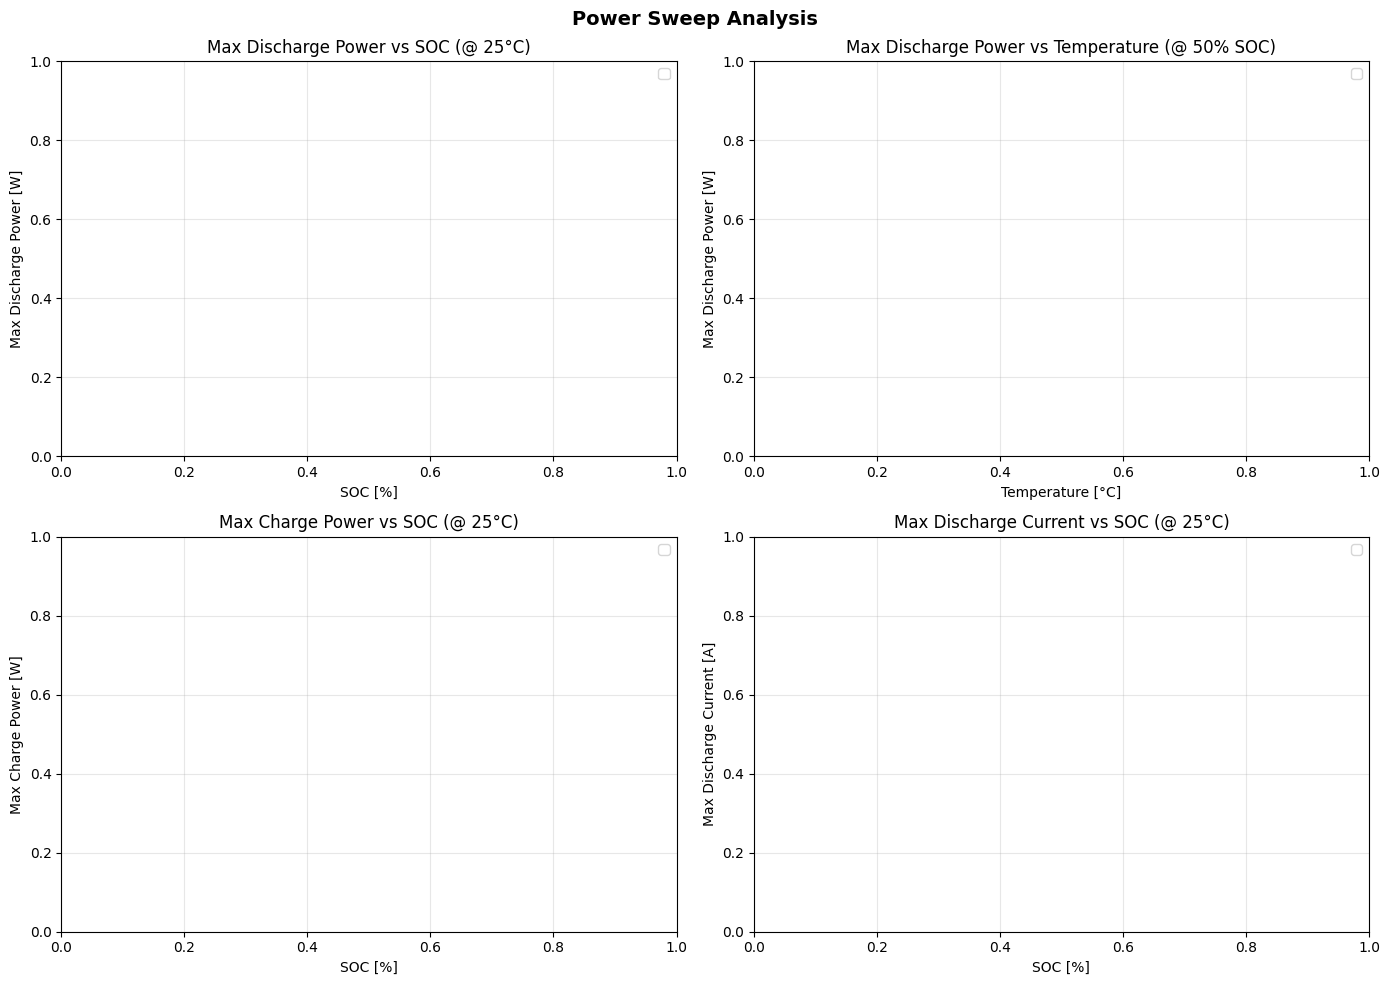

In [6]:
if len(power_metrics) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Max Discharge Power vs SOC (for different pulse durations)
    ax1 = axes[0, 0]
    for duration in pulse_durations_s:
        soc_vals = []
        power_vals = []
        for m in power_metrics:
            if abs(m['pulse_duration_s'] - duration) < 0.1 and abs(m['temperature_C'] - 25) < 1:
                soc_vals.append(m['soc'] * 100)
                power_vals.append(m['max_discharge_power_W'])
        if soc_vals:
            ax1.plot(sorted(zip(soc_vals, power_vals)), marker='o', label=f"{duration}s pulse")
    ax1.set_xlabel('SOC [%]')
    ax1.set_ylabel('Max Discharge Power [W]')
    ax1.set_title('Max Discharge Power vs SOC (@ 25°C)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Max Discharge Power vs Temperature (for 50% SOC)
    ax2 = axes[0, 1]
    for duration in pulse_durations_s:
        temp_vals = []
        power_vals = []
        for m in power_metrics:
            if abs(m['pulse_duration_s'] - duration) < 0.1 and abs(m['soc'] - 0.5) < 0.05:
                temp_vals.append(m['temperature_C'])
                power_vals.append(m['max_discharge_power_W'])
        if temp_vals:
            ax2.plot(sorted(zip(temp_vals, power_vals)), marker='s', label=f"{duration}s pulse")
    ax2.set_xlabel('Temperature [°C]')
    ax2.set_ylabel('Max Discharge Power [W]')
    ax2.set_title('Max Discharge Power vs Temperature (@ 50% SOC)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Max Charge Power vs SOC
    ax3 = axes[1, 0]
    for duration in pulse_durations_s:
        soc_vals = []
        power_vals = []
        for m in power_metrics:
            if abs(m['pulse_duration_s'] - duration) < 0.1 and abs(m['temperature_C'] - 25) < 1:
                soc_vals.append(m['soc'] * 100)
                power_vals.append(m['max_charge_power_W'])
        if soc_vals:
            ax3.plot(sorted(zip(soc_vals, power_vals)), marker='o', label=f"{duration}s pulse")
    ax3.set_xlabel('SOC [%]')
    ax3.set_ylabel('Max Charge Power [W]')
    ax3.set_title('Max Charge Power vs SOC (@ 25°C)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Discharge Current vs SOC
    ax4 = axes[1, 1]
    for duration in pulse_durations_s:
        soc_vals = []
        current_vals = []
        for m in power_metrics:
            if abs(m['pulse_duration_s'] - duration) < 0.1 and abs(m['temperature_C'] - 25) < 1:
                soc_vals.append(m['soc'] * 100)
                current_vals.append(m['max_discharge_current_A'])
        if soc_vals:
            ax4.plot(sorted(zip(soc_vals, current_vals)), marker='^', label=f"{duration}s pulse")
    ax4.set_xlabel('SOC [%]')
    ax4.set_ylabel('Max Discharge Current [A]')
    ax4.set_title('Max Discharge Current vs SOC (@ 25°C)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Power Sweep Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")
